In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 

In [6]:
df = pd.read_csv('Леденцы.dat', sep=';') # считываем файл
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
0,4,5,5,5,3,3,3,3,3,3,3
1,5,4,5,5,3,3,3,3,3,3,3
2,5,5,4,5,3,3,3,3,3,3,3
3,5,4,5,5,3,3,3,3,3,3,3
4,4,5,5,5,3,3,3,3,3,3,3


## Лабораторная работа 2

Ищем оптимальное число кластеров по методу каменистой осыпи

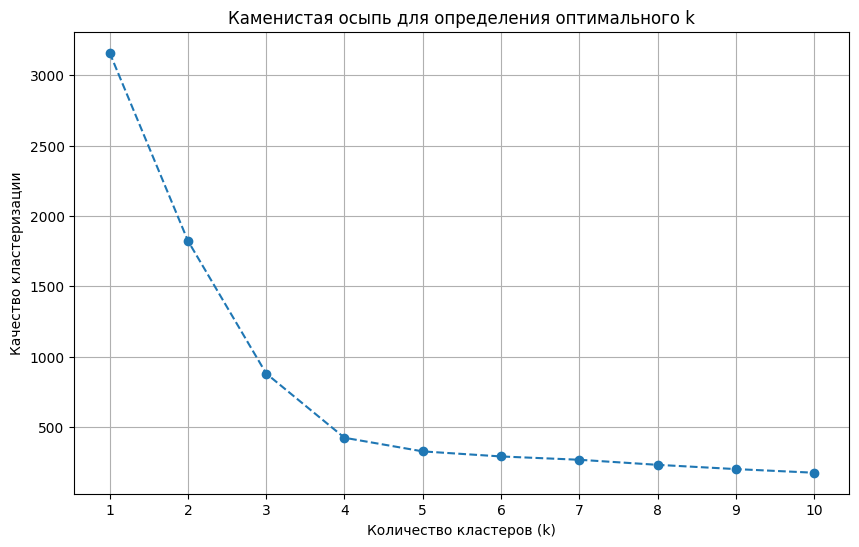

In [7]:
claster_quality = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df)
    claster_quality.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, claster_quality, marker='o', linestyle='--')
plt.title('Каменистая осыпь для определения оптимального k')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Качество кластеризации')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Видим, что после 4 кластеров добавление нового не несёт больших изменений.

In [8]:
K = 4
kmeans = KMeans(n_clusters=K)

# предсказываем метки классов
df['cluster_id'] = kmeans.fit_predict(df)
cluster_analysis = df.groupby('cluster_id').mean().round(2)
cluster_analysis

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
cluster_id,,,,,,,,,,,
0,2.82,2.83,2.77,2.62,2.61,2.58,2.75,2.92,4.95,4.81,4.86
1,3.00,3.00,3.00,3.00,4.85,4.85,3.00,2.92,2.75,2.75,2.75
2,4.85,4.80,4.84,4.68,3.04,3.04,3.00,2.99,3.07,3.05,3.05
3,3.00,2.97,2.97,2.92,2.92,2.95,4.92,4.92,3.00,3.00,3.00


Видим, что модель разбила данные на такие же кластеры, как и алгоритм иерархической кластеризации

Кластер 1: используют леденей как лекарство

Кластер 2: как замену сладкому

Кластер 3: как средство гигиены 

Кластер 4: для концентрации